<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implementando Lógica de Componentes Principais**

Use bodyfat-reduced.csv e faça uma análise de Componentes principais.

OBS: A Análise Fatorial busca explicar a covariância (correlação) entre as variáveis a partir de fatores ocultos. Já o PCA busca representar a variabilidade total dos dados originais com o menor número possível de componentes.

In [25]:
from matplotlib import pyplot as plt # importando a biblioteca de visualização de dados
import pandas as pd # importando a biblioteca de manipulação de dados
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler # para padronização
from sklearn.decomposition import PCA # para PCA

# URL COMPLETA da sua planilha
url = "https://docs.google.com/spreadsheets/d/1OMwAUcy2fj38SeW3oH9dlpTTDrdlWeUvf9pU-7FDbjw/edit?gid=270866260#gid=270866260"

# Transforma o link em formato de exportação CSV
url_csv = url.replace("/edit?", "/export?format=csv&")

# Lê os dados diretamente da planilha
base_banco = pd.read_csv(url_csv)
base_banco.head()

,BodyFat,Weight,Chest,Abdomen,Hip,Thigh,Biceps
0,12.3,154.25,93.1,85.2,94.5,59.0,32.0
1,6.1,173.25,93.6,83.0,98.7,58.7,30.5
2,25.3,154.00,95.8,87.9,99.2,59.6,28.8
3,10.4,184.75,101.8,86.4,101.2,60.1,32.4
4,28.7,184.25,97.3,100.0,101.9,63.2,32.2


In [26]:
# Descritiva
base_banco.describe()

,BodyFat,Weight,Chest,Abdomen,Hip,Thigh,Biceps
count,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000
mean,19.094422,178.190438,100.683267,92.334661,99.714343,59.294821,32.222709
std,8.338962,27.034801,8.144414,10.215190,6.508078,4.954547,2.917904
min,0.000000,118.500000,79.300000,69.400000,85.000000,47.200000,24.800000
25%,12.450000,158.750000,94.300000,84.550000,95.500000,56.000000,30.200000
50%,19.200000,176.250000,99.600000,90.900000,99.300000,59.000000,32.000000
75%,25.250000,196.875000,105.300000,99.200000,103.350000,62.300000,34.300000
max,47.500000,262.750000,128.300000,126.200000,125.600000,74.400000,39.100000


In [23]:
# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(base_banco)
X_scaled


array([[-8.16408267e-01, -8.87310814e-01, -9.32960721e-01, ...,
        -8.02811716e-01, -5.96239752e-02, -7.64775528e-02],
       [-1.56139158e+00, -1.83108773e-01, -8.71446289e-01, ...,
        -1.56170433e-01, -1.20295399e-01, -5.91572340e-01],
       [ 7.45653523e-01, -8.96576631e-01, -6.00782787e-01, ...,
        -7.91893280e-02,  6.17188717e-02, -1.17534643e+00],
       ...,
       [ 1.22628792e+00,  3.17245308e-01,  1.28155884e+00, ...,
         3.05716197e-01,  2.03285526e-01, -3.16855120e-01],
       [ 8.29764542e-01,  4.65498369e-01,  9.37078022e-01, ...,
        -2.94736422e-01, -6.66338210e-01, -5.91572340e-01],
       [ 1.53870028e+00,  1.08630806e+00,  1.44149637e+00, ...,
         1.13711213e+00,  1.04744821e-03,  5.07296540e-01]])

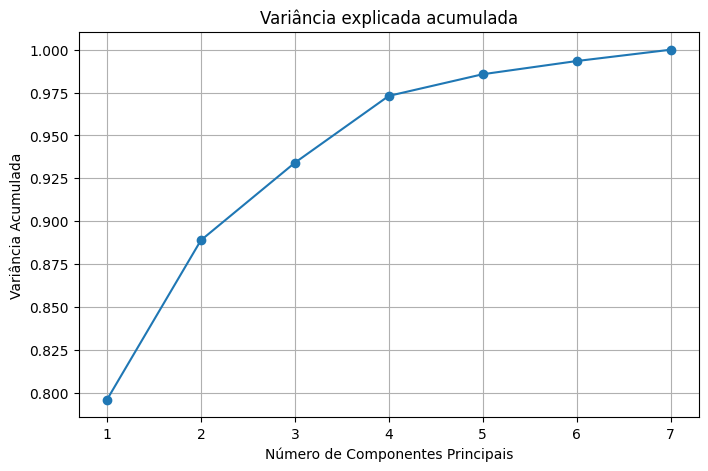

In [30]:
# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Visualizar variância explicada
variancia = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(range(1, len(variancia)+1), np.cumsum(variancia), marker='o')
plt.title('Variância explicada acumulada')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Acumulada')
plt.grid(True)
plt.show()

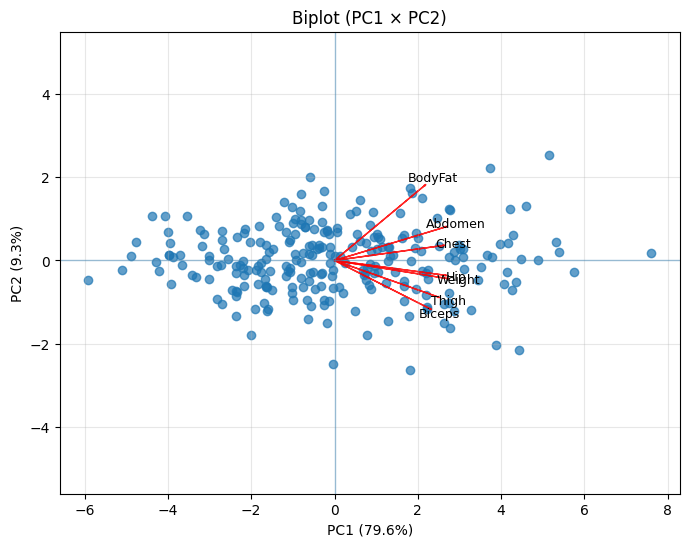

In [36]:
# Usando os dois primeiros componentes do PCA (pois é um gráfico 2D)
# Ou seja: existem mais componentes, mas o gráfico mostra só os dois primeiros (os mais informativos) por escolha de visualização.

# Scores das observações nos dois primeiros componentes
scores = X_pca[:, :2]

# Loadings (contribuição das variáveis) para PC1 e PC2
loadings = pca.components_.T[:, :2]

# Nomes das variáveis (mesma ordem das colunas usadas no fit)
var_names = list(base_banco.columns)

# Gráfico
plt.figure(figsize=(8, 6))
plt.scatter(scores[:, 0], scores[:, 1], alpha=0.7)
plt.axhline(0, linewidth=1, alpha=0.4)
plt.axvline(0, linewidth=1, alpha=0.4)

# Escala para os vetores ficarem proporcionais ao espalhamento dos scores
scale_x = (scores[:, 0].max() - scores[:, 0].min())
scale_y = (scores[:, 1].max() - scores[:, 1].min())
arrow_scale = 0.5  # ajuste fino do tamanho das setas (ex.: 0.3, 0.7, 1.0)

# Adiciona vetores das variáveis (loadings)
for i, name in enumerate(var_names):
    dx = loadings[i, 0] * scale_x * arrow_scale
    dy = loadings[i, 1] * scale_y * arrow_scale
    plt.arrow(0, 0, dx, dy,
              length_includes_head=True, head_width=0.03,
              alpha=0.85, color='red')
    plt.text(dx * 1.08, dy * 1.08, name,
             ha='center', va='center', fontsize=9)

pc1_pct = variancia[0] * 100
pc2_pct = variancia[1] * 100
plt.title('Biplot (PC1 × PC2)')
plt.xlabel(f'PC1 ({pc1_pct:.1f}%)')
plt.ylabel(f'PC2 ({pc2_pct:.1f}%)')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='datalim')
plt.show()

O gráfico de biplot mostra como as variáveis originais se relacionam com os dois primeiros componentes principais.
Neste caso, o primeiro componente (PC1) explica cerca de 79,6% da variância total, enquanto o segundo (PC2) explica mais 9,3%, somando quase 89% da informação dos dados originais. Isso indica que a maior parte da variação nas medidas corporais pode ser representada em apenas duas dimensões.

As setas vermelhas representam as variáveis originais — quanto mais longa a seta, maior a contribuição da variável para os componentes.
É possível observar que variáveis como “BodyFat”, “Abdomen” e “Weight” têm maior influência no PC1, sugerindo que elas estão fortemente associadas a uma dimensão de composição corporal.
Já o PC2 tem menor peso relativo, diferenciando observações com pequenas variações em regiões específicas do corpo (como Chest e Thigh).

Em resumo, o biplot mostra que a variação dos dados é amplamente explicada por um único eixo principal (PC1), o que sugere que as variáveis estão altamente correlacionadas e descrevem um mesmo fator latente relacionado à gordura corporal e medidas antropométricas.